In [1]:
!pip install plotly

In [2]:
!pip install anndata==0.8.0

In [3]:
!pip install -U kaleido

In [2]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import plotly.express as px
import time
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE

In [4]:
orgs = ['mg','mo','cj','ac','ri']
pairs = [list(pair) for pair in itertools.combinations(orgs, 2)]
level = 'eq_supertype'
for org_one, org_two in pairs:
    sm = load_samap('../../Subclustering/MNPO/sm_' + org_one + '_' + org_two + '_MNPO_09082026.pkl')
    print(org_one, org_two)
    df_plt = pd.DataFrame(columns = ['celltype_org','celltype_ref','mapping','num_cells'])
    a = 0
    keys = {org_one:level,org_two:level}
    D,MappingTable = get_mapping_scores(sm,keys)

    lim_MappingTable = MappingTable.filter(like=org_one + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two + '_')]
    lim_MappingTable.to_csv('../../Subclustering/MNPO/Hypo/' + org_one + '_' + org_two + '_mapping_MNPO_09092026_clusters.csv')

mg mo
mg cj
mg ac
mg ri
mo cj
mo ac
mo ri
cj ac
cj ri
ac ri


In [5]:
#all dfs load
ct = 'MNPO'
organisms = ['mg', 'mo', 'cj', 'ac', 'ri']
level = 'eq_supertype'

def read_pair(a, b):
    return pd.read_csv(
        f'../../Subclustering/{ct}/Hypo/{a}_{b}_mapping_{ct}_09092026_clusters.csv',
        index_col='Unnamed: 0')

labels = {}
for i, a in enumerate(organisms):
    for b in organisms[i+1:]:
        df = read_pair(a, b)
        labels.setdefault(a, list(df.columns))
        labels.setdefault(b, list(df.index))

mapping = {}
for i, org1 in enumerate(organisms):
    for j, org2 in enumerate(organisms):
        key = f"{org1}_{org2}".upper()
        if i == j:
            u = labels[org1]
            mapping[key] = pd.DataFrame(np.eye(len(u)), index=u, columns=u)
        elif i < j:
            mapping[key] = read_pair(org1, org2)
        else:
            mapping[key] = mapping[f"{org2}_{org1}".upper()].T

In [6]:
organism_rows = {}
for org1 in organisms:
    dfs = [mapping[f"{org1}_{org2}".upper()] for org2 in organisms]
    organism_rows[org1.upper()] = pd.concat(dfs)

In [7]:
pvh_mapping = pd.concat([organism_rows[i.upper()] for i in organisms], axis = 1)

<AxesSubplot:>

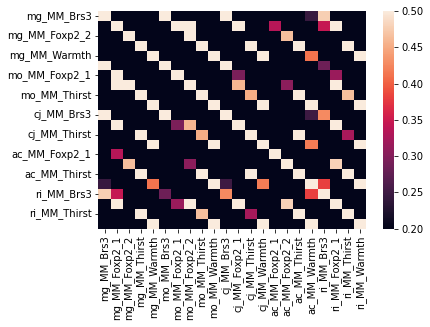

In [8]:
sns.heatmap(pvh_mapping, vmin = .2, vmax = .5)

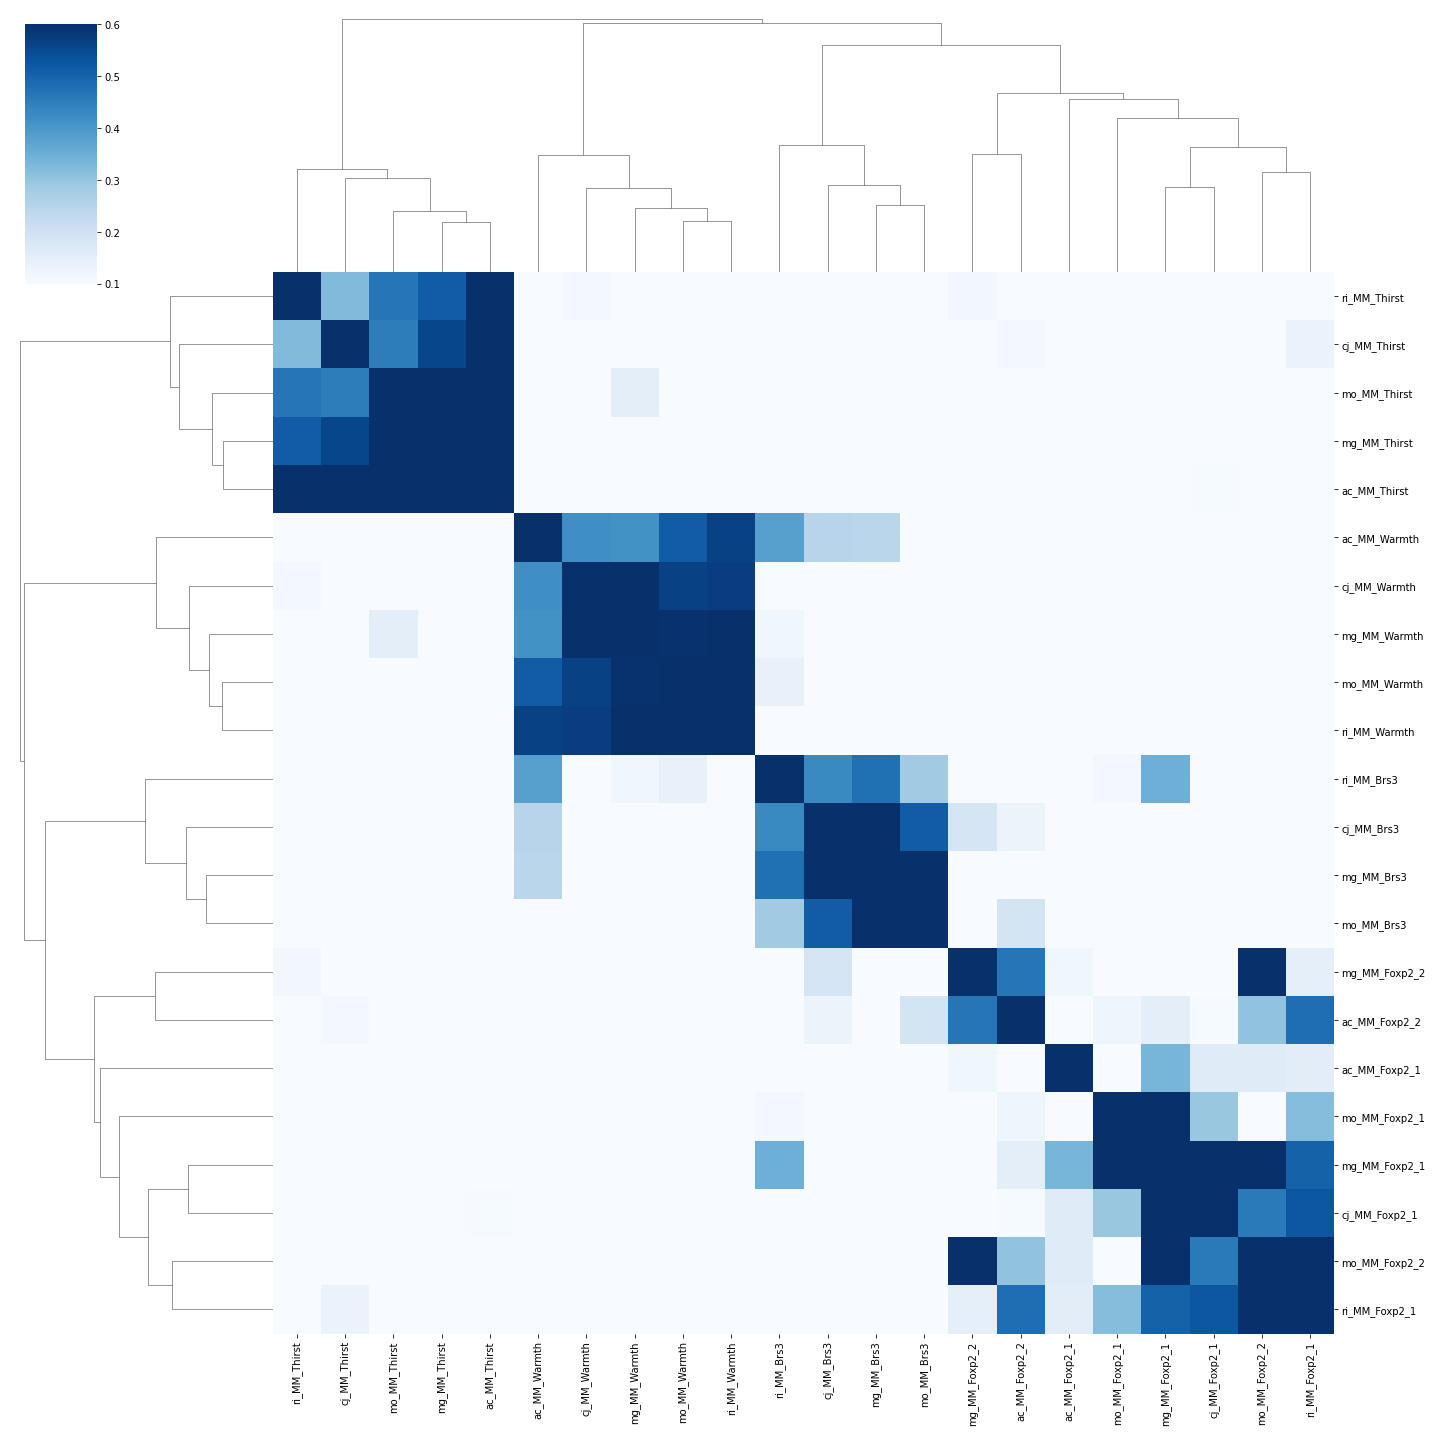

In [9]:
g =sns.clustermap(pvh_mapping, vmax = .6, vmin = .1,cmap = 'Blues',figsize=(20,20))
#plt.savefig('MNPO_mapping_hypothalamus_04102026.svg')

In [10]:
reorder_row = g.dendrogram_row.reordered_ind
reorder_col = g.dendrogram_col.reordered_ind

In [11]:
pvh_mapping.index[reorder_row]

Index(['ri_MM_Thirst', 'cj_MM_Thirst', 'mo_MM_Thirst', 'mg_MM_Thirst',
       'ac_MM_Thirst', 'ac_MM_Warmth', 'cj_MM_Warmth', 'mg_MM_Warmth',
       'mo_MM_Warmth', 'ri_MM_Warmth', 'ri_MM_Brs3', 'cj_MM_Brs3',
       'mg_MM_Brs3', 'mo_MM_Brs3', 'mg_MM_Foxp2_2', 'ac_MM_Foxp2_2',
       'ac_MM_Foxp2_1', 'mo_MM_Foxp2_1', 'mg_MM_Foxp2_1', 'cj_MM_Foxp2_1',
       'mo_MM_Foxp2_2', 'ri_MM_Foxp2_1'],
      dtype='object')

In [12]:
reorder = ['mg_MM_Thirst','mo_MM_Thirst','cj_MM_Thirst','ac_MM_Thirst', 'ri_MM_Thirst',  
        'mg_MM_Warmth','mo_MM_Warmth','cj_MM_Warmth','ac_MM_Warmth','ri_MM_Warmth',
           'mg_MM_Foxp2_1','mo_MM_Foxp2_1','cj_MM_Foxp2_1','ac_MM_Foxp2_1',
           'mg_MM_Foxp2_2', 'mo_MM_Foxp2_2','ac_MM_Foxp2_2','ri_MM_Foxp2_1',
         'mg_MM_Brs3', 'mo_MM_Brs3','cj_MM_Brs3','ri_MM_Brs3']

In [13]:
for item in pvh_mapping.index:
    if item not in reorder:
        print(item)

In [15]:
print(len(reorder), len(set(reorder)))

22 22


In [16]:
pvh_mapping_ord = pvh_mapping.loc[reorder,:]
pvh_mapping_ord = pvh_mapping_ord.loc[:,reorder]

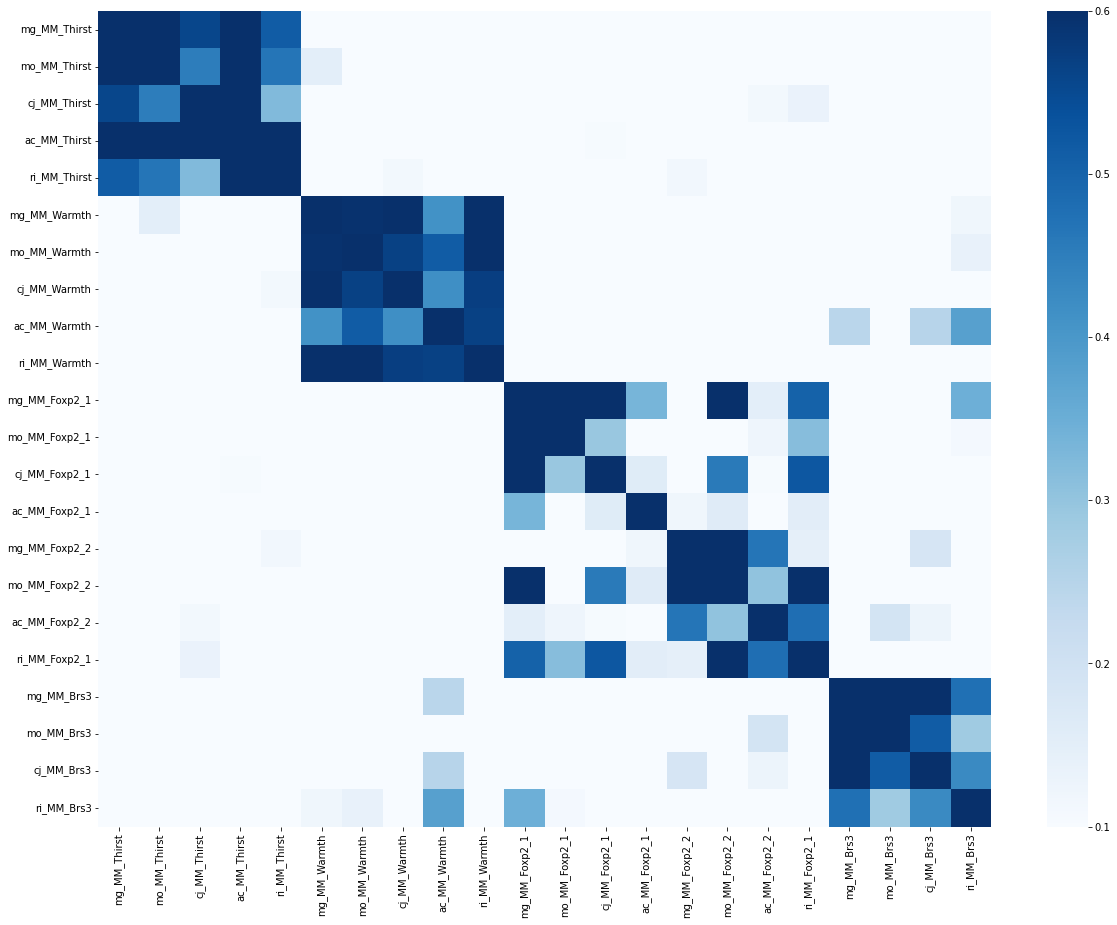

In [17]:
plt.figure(figsize = (20,15))
sns.heatmap(pvh_mapping_ord, vmax = .6, vmin = .1,cmap = 'Blues')
plt.savefig('../../Figures/Figures_09132026/MNPO_boxplot_hypothalamusri_09092026.svg',bbox_inches='tight')
plt.savefig('../../Figures/Figures_09132026/MNPO_boxplot_hypothalamusri_09092026.pdf',bbox_inches='tight')